In [1]:
import sys
import os
import glob
import pandas as pd
import numpy as np
from datetime import datetime

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import struct


import funciones_aux as fau

import funciones_dsa as fun_dsa
import funciones_dsa_unilateral as fun_dsa_u
import funciones_dsa_bilateral as fun_dsa_b

import funciones_plot_dsa as fun_plot

from scipy.signal import welch
from matplotlib.colors import LinearSegmentedColormap, PowerNorm
from scipy.stats import pearsonr, spearmanr


# 1. Unilateral

In [2]:
ruta_fa_unilat = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_advanced/M-TA6m-03041035/DH03041035/L03041035.f_a"
ruta_spa_unilat = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_advanced/M-TA6m-03041035/DH03041035/L03041035.spa"
ruta_ha_unilat = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_advanced/M-TA6m-03041035/DH03041035/L03041035.h_a"
ruta_ta_unilat = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_advanced/M-TA6m-03041035/DH03041035/L03041035.t_a"

archivo_r2a = r"C:/Users/usuario/TFG_BIS_GIS/data/data_bis_advanced/M-TA6m-03041035/DH03041035/L03041035.r2a"

## 1. 1.  Archivo Espectral .f_a

In [3]:
tiempo_fa_unilat, dsa_unilat = fau.cargar_fa_directo(ruta_fa_unilat, escalar_db=True)

print("Dimensiones de la matriz:", dsa_unilat.shape)
print("Frecuencias:", dsa_unilat.columns.min(), "a", dsa_unilat.columns.max(), "Hz")

Dimensiones de la matriz: (2119, 60)
Frecuencias: 0.5 a 30.0 Hz


## 1. 2. Archivo variables procesadas .spa

In [4]:
df_spa_raw = fau.procesar_spa(ruta_spa_unilat)
df_spa_unilat = fun_dsa_u.limpiar_spa_unilateral(df_spa_raw)

print("Dimensiones del archivo procesado:", df_spa_unilat.shape)

Dimensiones del archivo procesado: (2119, 11)


### Fusión de los anteriores

In [5]:
df_merge_fa = fun_dsa.alinear_spa_con_tiempo(tiempo_fa_unilat, df_spa_unilat)
sef_hor = df_merge_fa["SEF08"]
mf_hor = df_merge_fa["MEDFRQ08"]

dsa_plot_fa, mask_total_fa = fun_dsa.preparar_dsa_con_mask(tiempo_fa_unilat, dsa_unilat, df_merge_fa)


### Cabecera

In [6]:
num_canales, fs, pendiente, offset = fau.extraer_parametros_eeg(ruta_ha_unilat)
print("Parámetros extraídos con éxito:")
print(f" - Canales: {num_canales}")
print(f" - Frecuencia (Hz): {fs}")
print(f" - Pendiente (m): {pendiente:.8f}")
print(f" - Offset (b): {offset:.4f}")

Parámetros extraídos con éxito:
 - Canales: 2
 - Frecuencia (Hz): 128
 - Pendiente (m): 0.05000000
 - Offset (b): -3234.0000


## 1. 3 Archivo ondas crudas .r2a

In [7]:
df_eeg = fun_dsa_u.leer_r2a(
    archivo_r2a,
    pendiente,
    offset,
    fs=fs
)

# 2. Bilateral - Advanced

In [8]:
ruta_fa_bilat = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_advanced/bilateral/L05141322/L05141322.f_a"
ruta_spa_bilat = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_advanced/bilateral/L05141322/L05141322.spa"
ruta_ha_bilat = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_advanced/bilateral/L05141322/L05141322.h_a"
ruta_ta_bilat = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_advanced/bilateral/L05141322/L05141322.t_a"

archivo_r4a = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_advanced/bilateral/L05141322/L05141322.r4a"

## 2. 1. Archivo Espectral .f_a

In [9]:
tiempo_fa_bilat, dsa_fa_L, dsa_fa_R = fau.cargar_fa_bilateral(
    ruta_fa_bilat,
    escalar_db=True
)

print("Dimensiones del archivo hemisferio izquierdo:", dsa_fa_L.shape)
print("Dimensiones del archivo hemisferio derecho:", dsa_fa_R.shape)

Dimensiones del archivo hemisferio izquierdo: (2712, 60)
Dimensiones del archivo hemisferio derecho: (2712, 60)


## 2. 2. Archivo variables procesadas .spa

In [11]:
df_spa_raw_bilat = fau.procesar_spa(ruta_spa_bilat)
df_spa_bilat = fun_dsa_b.limpiar_spa_bilateral(df_spa_raw_bilat)

print("Dimensiones del archivo procesado:", df_spa_bilat.shape)
print(df_spa_bilat.columns.tolist())
display(df_spa_bilat.head())

Dimensiones del archivo procesado: (2712, 32)
['Time', 'SpSmooth', 'SR12_izq', 'SEF08_izq', 'MEDFRQ08_izq', 'BISBIT00_izq', 'DB13U01_izq', 'DB11U04_izq', 'B34U05_izq', 'TOTPOW08_izq', 'EMGLOW01_izq', 'SQI10_izq', 'IMPEDNCE_izq', 'ARTF2_izq', 'BURST_izq', 'ST_izq', 'SR12_der', 'SEF08_der', 'MEDFRQ08_der', 'BISBIT00_der', 'DB13U01_der', 'DB11U04_der', 'B34U05_der', 'TOTPOW08_der', 'EMGLOW01_der', 'SQI10_der', 'IMPEDNCE_der', 'ARTF2_der', 'BURST_der', 'ST_der', 'ASYM09', 'modo_spa']


,Time,SpSmooth,SR12_izq,SEF08_izq,MEDFRQ08_izq,BISBIT00_izq,DB13U01_izq,DB11U04_izq,B34U05_izq,TOTPOW08_izq,...,B34U05_der,TOTPOW08_der,EMGLOW01_der,SQI10_der,IMPEDNCE_der,ARTF2_der,BURST_der,ST_der,ASYM09,modo_spa
0,2026-05-14 13:22:51,3,0.0,16.7,2.7,NaN,91.7,NaN,NaN,68.5,...,NaN,67.4,44.4,76.9,2.3,0.0,NaN,0.0,47.1,bilateral
1,2026-05-14 13:22:52,3,0.0,16.7,2.7,NaN,91.3,NaN,NaN,68.4,...,NaN,67.4,44.4,78.2,1.8,0.0,NaN,0.0,47.1,bilateral
2,2026-05-14 13:22:53,3,0.0,16.7,2.7,NaN,91.3,NaN,NaN,68.4,...,NaN,67.6,44.9,79.5,1.9,8.0,NaN,0.0,47.1,bilateral
3,2026-05-14 13:22:54,3,0.0,16.7,2.7,NaN,91.2,NaN,NaN,68.4,...,NaN,67.6,45.1,79.5,2.5,0.0,NaN,0.0,47.1,bilateral
4,2026-05-14 13:22:55,3,0.0,16.7,2.6,NaN,90.0,NaN,NaN,68.4,...,NaN,67.2,45.3,80.1,2.2,0.0,NaN,0.0,46.5,bilateral


### Extraer cada hemisferio con nombres estándar

In [12]:
df_spa_L = fun_dsa_b.extraer_lado_spa_bilateral(
    df_spa_bilat,
    lado="izq",
    verbose=False
)

df_spa_R = fun_dsa_b.extraer_lado_spa_bilateral(
    df_spa_bilat,
    lado="der",
    verbose=False
)


###  Fusión .f_a y .spa

In [13]:
df_merge_fa_L = fun_dsa.alinear_spa_con_tiempo(
    tiempo_fa_bilat,
    df_spa_L
)

df_merge_fa_R = fun_dsa.alinear_spa_con_tiempo(
    tiempo_fa_bilat,
    df_spa_R
)

# Curvas del BIS por hemisferio
sef_fa_L = df_merge_fa_L["SEF08"]
mef_fa_L = df_merge_fa_L["MEDFRQ08"]

sef_fa_R = df_merge_fa_R["SEF08"]
mef_fa_R = df_merge_fa_R["MEDFRQ08"]

#### Máscaras

In [14]:
# Preparar DSA .f_a izquierda y derecha con sus máscaras
dsa_plot_fa_L, mask_total_fa_L = fun_dsa.preparar_dsa_con_mask(
    tiempo_fa_bilat,
    dsa_fa_L,
    df_merge_fa_L
)

dsa_plot_fa_R, mask_total_fa_R = fun_dsa.preparar_dsa_con_mask(
    tiempo_fa_bilat,
    dsa_fa_R,
    df_merge_fa_R
)

In [15]:
# Máscara común para comparar ambos hemisferios visualmente
mask_total_fa_bilat = mask_total_fa_L | mask_total_fa_R

dsa_plot_fa_L_mask = dsa_plot_fa_L.copy()
dsa_plot_fa_R_mask = dsa_plot_fa_R.copy()

dsa_plot_fa_L_mask.loc[mask_total_fa_bilat.values, :] = np.nan
dsa_plot_fa_R_mask.loc[mask_total_fa_bilat.values, :] = np.nan

In [16]:
frecuencias_fa = dsa_plot_fa_L_mask.columns.astype(float)

matriz_fa_L, matriz_fa_R, vmin_fa, vmax_fa, norm_fa_bilat, cmap_fa_bilat = (
    fun_dsa_b.preparar_escala_color_dsa_bilateral(
        dsa_plot_fa_L_mask,
        dsa_plot_fa_R_mask,
        vmin=49,
        vmax=94,
        gamma=1
    )
)

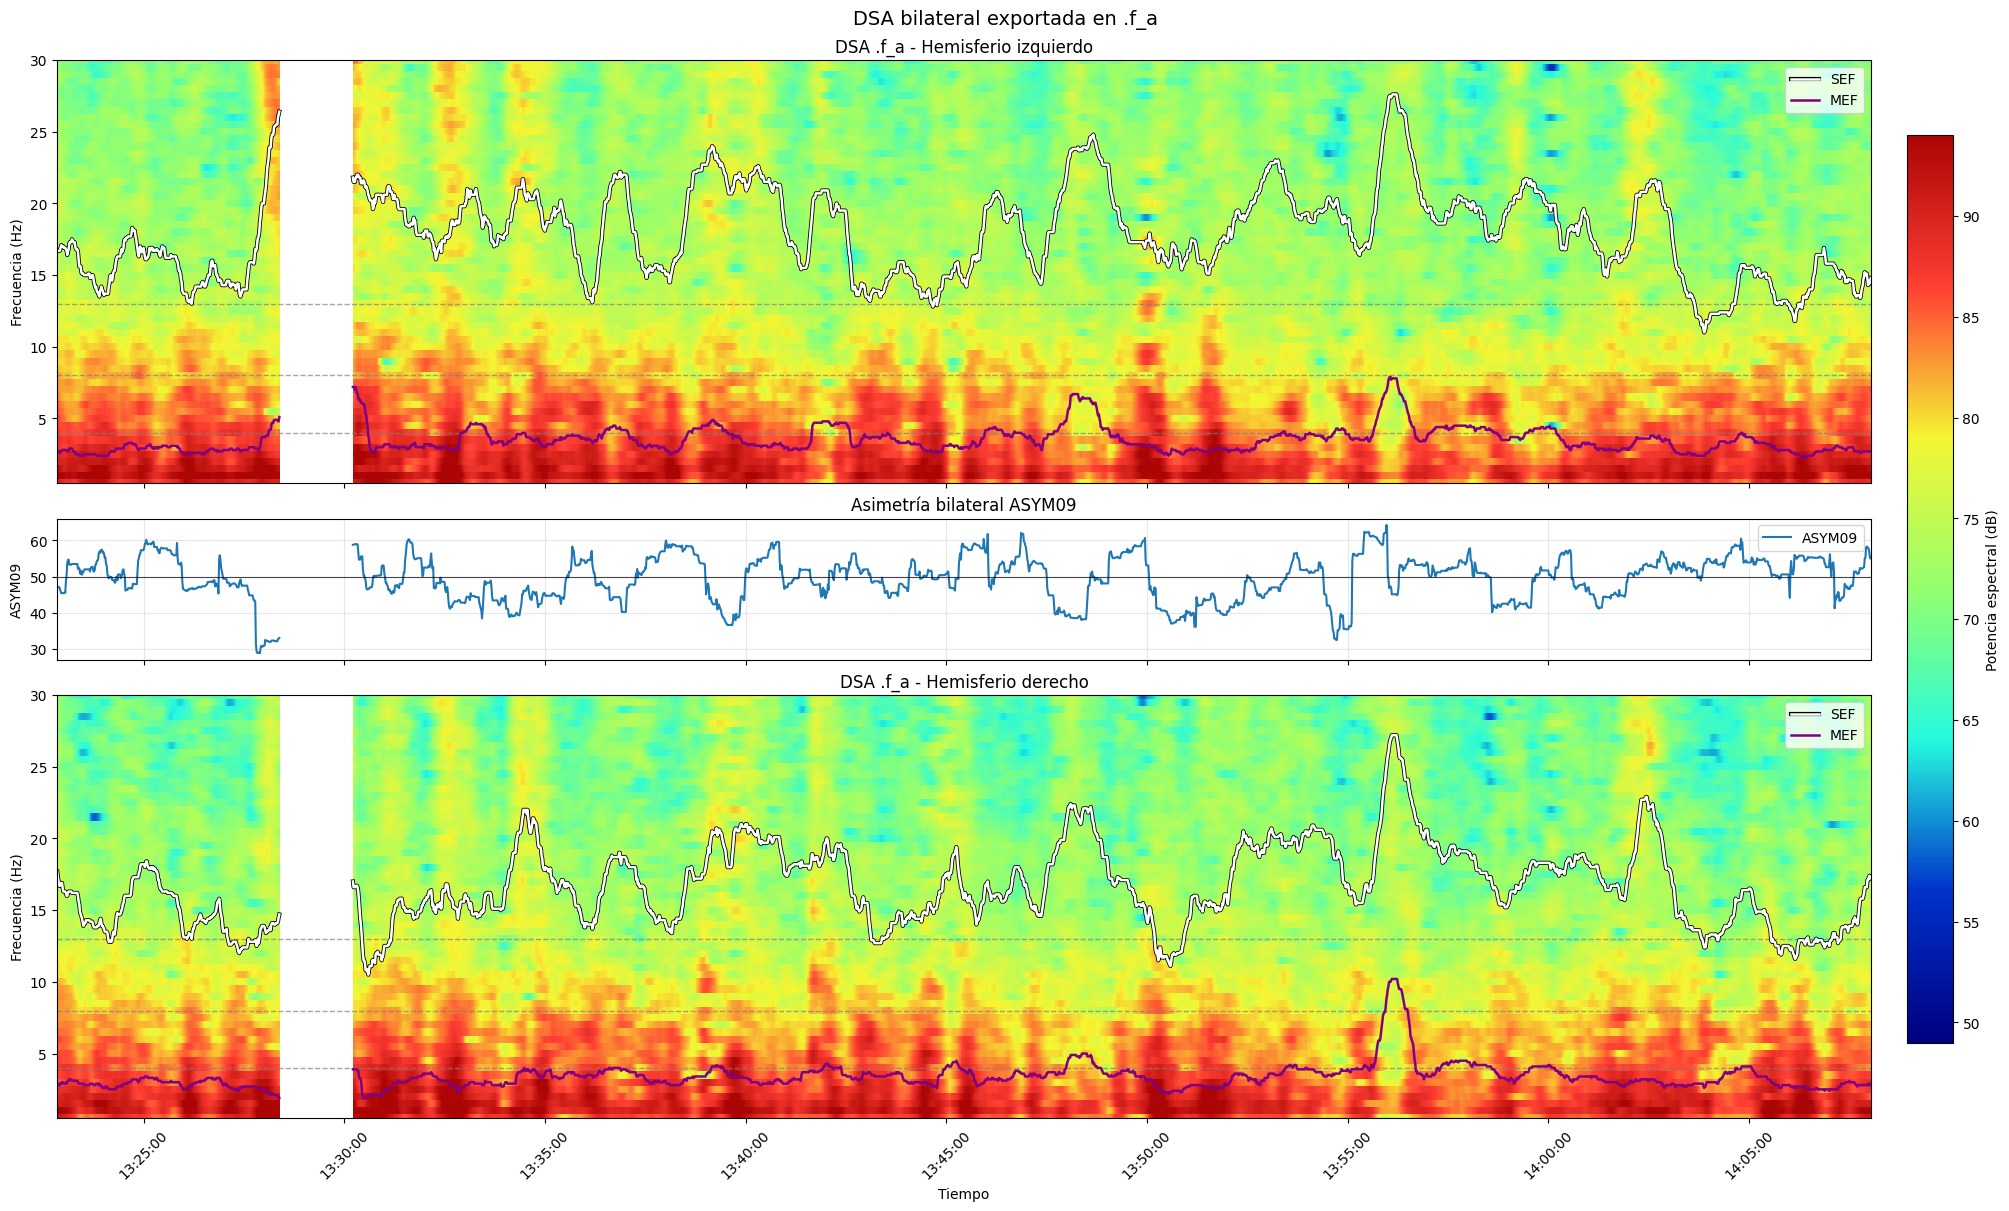

In [17]:
fig, axes = fun_plot.plot_dsa_bilateral_con_sef_mef(
    tiempo=tiempo_fa_bilat,
    frecuencias=frecuencias_fa,
    matriz_izq=matriz_fa_L,
    matriz_der=matriz_fa_R,
    norm=norm_fa_bilat,
    cmap=cmap_fa_bilat,
    df_merge_izq=df_merge_fa_L,
    df_merge_der=df_merge_fa_R,
    mask_izq=mask_total_fa_bilat,
    mask_der=mask_total_fa_bilat,
    asimetria=df_merge_fa_L["ASYM09"],
    titulo_izq="DSA .f_a - Hemisferio izquierdo",
    titulo_der="DSA .f_a - Hemisferio derecho",
    titulo_general="DSA bilateral exportada en .f_a",
    etiqueta_colorbar="Potencia espectral (dB)"
)

### Cabecera

In [18]:
num_canales_bil, fs_bil, pendiente_bil, offset_bil = fau.extraer_parametros_eeg(ruta_ha_bilat)
print("Parámetros extraídos con éxito:")
print(f" - Canales: {num_canales_bil}")
print(f" - Frecuencia (Hz): {fs_bil}")
print(f" - Pendiente (m): {pendiente_bil:.8f}")
print(f" - Offset (b): {offset_bil:.4f}")

Parámetros extraídos con éxito:
 - Canales: 4
 - Frecuencia (Hz): 128
 - Pendiente (m): 0.05000000
 - Offset (b): -3234.0000


## 2. 3. Archivo ondas crudas .r4a

In [19]:
df_eeg_bilateral = fun_dsa_b.leer_r4a(
    archivo_r4a, 
    pendiente_bil,
    offset_bil, 
    fs=fs_bil)

In [20]:
# Recortar el raw para que empiece donde empieza el .spa
# y dure lo mismo que el .spa.
df_eeg_bilat_recortado = fun_dsa_b.recortar_raw_segun_ta_y_spa(
    df_raw=df_eeg_bilateral,
    ruta_ta=ruta_ta_bilat,
    df_spa=df_spa_bilat,
    columna_time="Time",
    fs=128,
    verbose=True
)

print("Raw bilateral original:", df_eeg_bilateral.shape)
print("Raw bilateral recortado:", df_eeg_bilat_recortado.shape)

=== Recorte temporal raw vs spa ===
Inicio raw (.t_a): 2026-05-14 13:22:51
Inicio .spa: 2026-05-14 13:22:51
Desfase inicial: 0.0 s
Muestras recortadas al inicio: 0
Filas .spa: 2712
Muestras objetivo: 347136
Muestras raw antes: 347200
Muestras raw después: 347136
Muestras sobrantes al final: 64
Segundos sobrantes al final: 0.5
Raw bilateral original: (347200, 9)
Raw bilateral recortado: (347136, 9)


### 2. 3. 1. Reconstrucción

In [21]:
# ============================================================
# 2.2. Reconstrucción DSA por canal
# ============================================================

ventana_welch_s = 1
paso_welch_s = 1

df_dsa_canal1, frecuencias_c1 = fun_dsa.crear_matriz_dsa_fft_welch_desde_eeg(
    df_eeg_bilat_recortado,
    "canal_1_uV",
    fs=fs,
    ventana_seg=ventana_welch_s,
    paso_seg=paso_welch_s,
    fmin=0.5,
    fmax=30.0,
    paso_freq=0.5,
    modo="densidad",
    tiempo_referencia="centro"
)

df_dsa_canal2, _ = fun_dsa.crear_matriz_dsa_fft_welch_desde_eeg(
    df_eeg_bilat_recortado,
    "canal_2_uV",
    fs=fs,
    ventana_seg=ventana_welch_s,
    paso_seg=paso_welch_s,
    fmin=0.5,
    fmax=30.0,
    paso_freq=0.5,
    modo="densidad",
    tiempo_referencia="centro"
)

df_dsa_canal3, _ = fun_dsa.crear_matriz_dsa_fft_welch_desde_eeg(
    df_eeg_bilat_recortado,
    "canal_3_uV",
    fs=fs,
    ventana_seg=ventana_welch_s,
    paso_seg=paso_welch_s,
    fmin=0.5,
    fmax=30.0,
    paso_freq=0.5,
    modo="densidad",
    tiempo_referencia="centro"
)

df_dsa_canal4, _ = fun_dsa.crear_matriz_dsa_fft_welch_desde_eeg(
    df_eeg_bilat_recortado,
    "canal_4_uV",
    fs=fs,
    ventana_seg=ventana_welch_s,
    paso_seg=paso_welch_s,
    fmin=0.5,
    fmax=30.0,
    paso_freq=0.5,
    modo="densidad",
    tiempo_referencia="centro"
)

In [22]:
# Combinación por hemisferio en escala lineal

cols_freq = [c for c in df_dsa_canal1.columns if c != "tiempo_s"]

# Izquierda: canal 1 + canal 2
pot_media_izq = (
    df_dsa_canal1[cols_freq].to_numpy(dtype=float) +
    df_dsa_canal2[cols_freq].to_numpy(dtype=float)
) / 2

# Derecha: canal 3 + canal 4
pot_media_der = (
    df_dsa_canal3[cols_freq].to_numpy(dtype=float) +
    df_dsa_canal4[cols_freq].to_numpy(dtype=float)
) / 2

df_dsa_izq = df_dsa_canal1.copy()
df_dsa_der = df_dsa_canal3.copy()

In [23]:
# Conversión a dB para visualización

ref_potencia = 0.0001

df_dsa_izq[cols_freq] = 10 * np.log10(
    (pot_media_izq + 1e-12) / (ref_potencia ** 2)
)

df_dsa_der[cols_freq] = 10 * np.log10(
    (pot_media_der + 1e-12) / (ref_potencia ** 2)
)

### 2. 3. 2. Adaptación temporal, máscara y plot de DSA EEG

In [24]:
df_spa_bilat, hora_inicio = fun_dsa.obtener_hora_inicio_desde_spa(
    df_spa_bilat
)

tiempo_eeg_bilat, dsa_eeg_izq = fun_dsa.adaptar_dsa_reconstruida_para_plot(
    df_dsa=df_dsa_izq,
    frecuencias=frecuencias_c1,
    hora_inicio=hora_inicio,
    insertar_fila_inicial_nan=False
)

_, dsa_eeg_der = fun_dsa.adaptar_dsa_reconstruida_para_plot(
    df_dsa=df_dsa_der,
    frecuencias=frecuencias_c1,
    hora_inicio=hora_inicio,
    insertar_fila_inicial_nan=False
)

In [25]:
df_spa_izq = fun_dsa_b.extraer_lado_spa_bilateral(
    df_spa_bilat,
    lado="izq",
    verbose=False
)

df_spa_der = fun_dsa_b.extraer_lado_spa_bilateral(
    df_spa_bilat,
    lado="der",
    verbose=False
)

df_merge_eeg_izq = fun_dsa.alinear_spa_con_tiempo(
    tiempo=tiempo_eeg_bilat,
    df_spa=df_spa_izq
)

df_merge_eeg_der = fun_dsa.alinear_spa_con_tiempo(
    tiempo=tiempo_eeg_bilat,
    df_spa=df_spa_der
)

In [26]:
# Máscaras de calidad bilateral

_, mask_total_izq = fun_dsa.preparar_dsa_con_mask(
    tiempo=tiempo_eeg_bilat,
    dsa=dsa_eeg_izq,
    df_merge=df_merge_eeg_izq,
    umbral_sqi=15,
    umbral_ceros=0.9
)

_, mask_total_der = fun_dsa.preparar_dsa_con_mask(
    tiempo=tiempo_eeg_bilat,
    dsa=dsa_eeg_der,
    df_merge=df_merge_eeg_der,
    umbral_sqi=15,
    umbral_ceros=0.9
)

# Máscara común para que izquierda y derecha tengan bandas blancas alineadas
mask_total_bilat = mask_total_izq | mask_total_der

dsa_eeg_izq_plot = dsa_eeg_izq.copy()
dsa_eeg_der_plot = dsa_eeg_der.copy()

dsa_eeg_izq_plot.loc[mask_total_bilat.values, :] = np.nan
dsa_eeg_der_plot.loc[mask_total_bilat.values, :] = np.nan

### 2. 3. 3. Preparar escala de color de f_a y eeg reconstruida

In [27]:
matriz_eeg_izq, matriz_eeg_der, vmin_eeg, vmax_eeg, norm_eeg_bilat, cmap_eeg_bilat = (
    fun_dsa_b.preparar_escala_color_dsa_bilateral(
        dsa_eeg_izq_plot,
        dsa_eeg_der_plot,
        gamma=0.4,
        percentil_min=2,
        percentil_max=99.5
    )
)

print("Reconstruida bilateral")
print("vmin:", vmin_eeg)
print("vmax:", vmax_eeg)

Reconstruida bilateral
vmin: 66.48956602706717
vmax: 110.00568787465423


### 2. 3. 4. Visualizar reconstruidas desde .r4a

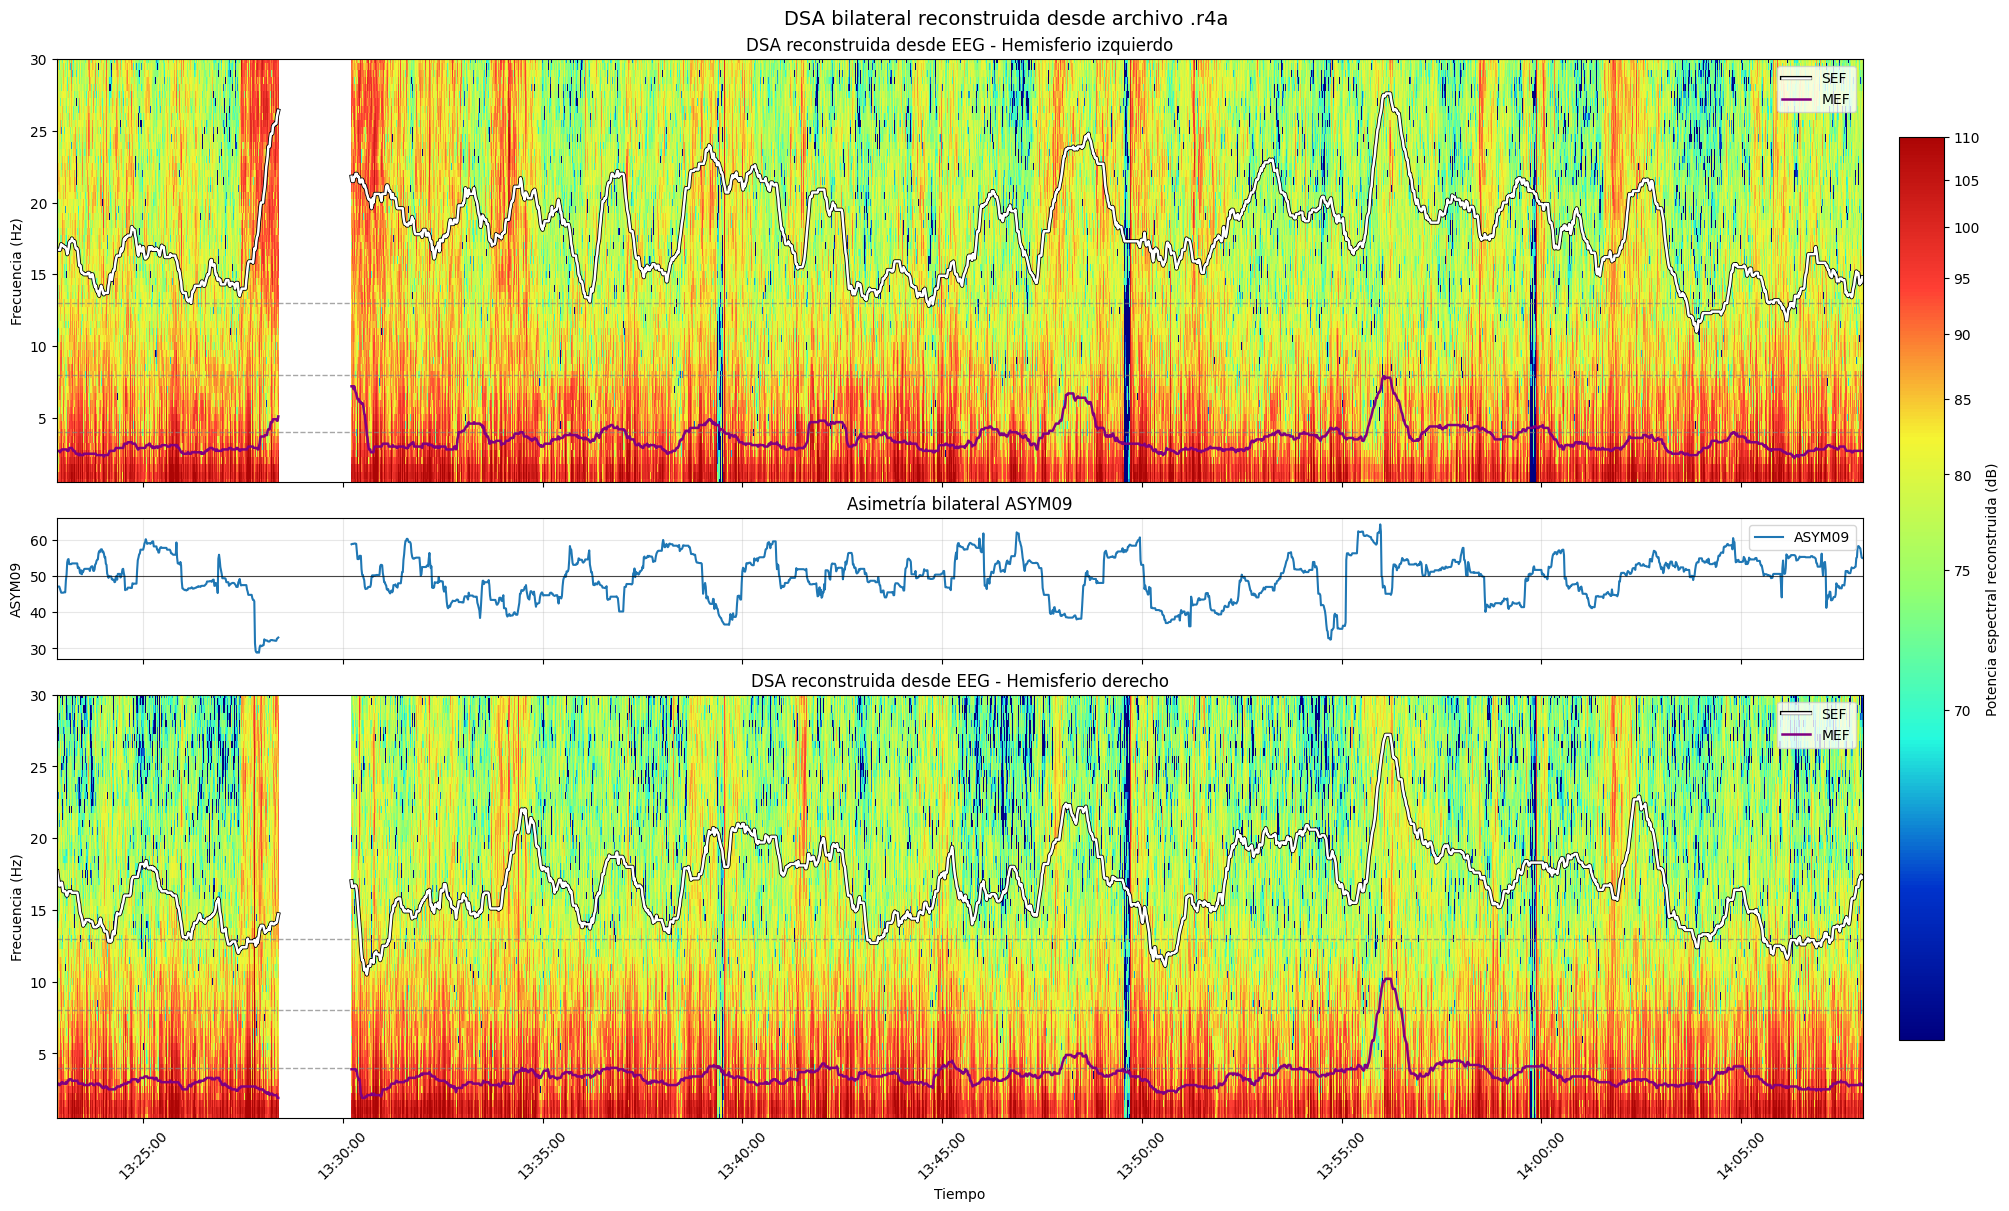

In [28]:
fig, axes = fun_plot.plot_dsa_bilateral_con_sef_mef(
    tiempo=tiempo_eeg_bilat,
    frecuencias=dsa_eeg_izq_plot.columns.astype(float),
    matriz_izq=matriz_eeg_izq,
    matriz_der=matriz_eeg_der,
    norm=norm_eeg_bilat,
    cmap=cmap_eeg_bilat,
    df_merge_izq=df_merge_eeg_izq,
    df_merge_der=df_merge_eeg_der,
    mask_izq=mask_total_bilat,
    mask_der=mask_total_bilat,
    asimetria=df_merge_eeg_izq["ASYM09"] if "ASYM09" in df_merge_eeg_izq.columns else None,
    titulo_izq="DSA reconstruida desde EEG - Hemisferio izquierdo",
    titulo_der="DSA reconstruida desde EEG - Hemisferio derecho",
    titulo_general="DSA bilateral reconstruida desde archivo .r4a",
    etiqueta_colorbar="Potencia espectral reconstruida (dB)"
)

In [29]:
cols_freq_eeg_L = [c for c in dsa_eeg_izq_plot.columns]

print("Mínimos y máximos hemisferio izquierdo - RECONSTRUCCIÓN")
print(np.nanmin(dsa_eeg_izq_plot[cols_freq_eeg_L].values))
print(np.nanmax(dsa_eeg_izq_plot[cols_freq_eeg_L].values))

print("Percentiles mínimos y máximos hemisferio izquierdo")
print(np.nanpercentile(dsa_eeg_izq_plot[cols_freq_eeg_L].values, 2))
print(np.nanpercentile(dsa_eeg_izq_plot[cols_freq_eeg_L].values, 99.5))

Mínimos y máximos hemisferio izquierdo - RECONSTRUCCIÓN
46.16160086071149
122.50951504083179
Percentiles mínimos y máximos hemisferio izquierdo
67.41939834993671
109.56019345995368


In [30]:
cols_freq_fa_L = [c for c in dsa_plot_fa_L_mask.columns]

print("Mínimos y máximos hemisferio izquierdo - FA")
print(np.nanmin(dsa_plot_fa_L_mask[cols_freq_fa_L].values))
print(np.nanmax(dsa_plot_fa_L_mask[cols_freq_fa_L].values))

print("Percentiles mínimos y máximos hemisferio izquierdo")
print(np.nanpercentile(dsa_plot_fa_L_mask[cols_freq_fa_L].values, 2))
print(np.nanpercentile(dsa_plot_fa_L_mask[cols_freq_fa_L].values, 99.5))

Mínimos y máximos hemisferio izquierdo - FA
55.75
98.29
Percentiles mínimos y máximos hemisferio izquierdo
67.11
94.27


In [31]:
cols_freq_eeg_R = [c for c in dsa_eeg_der_plot.columns]

print("Mínimos y máximos hemisferio derecho - RECONSTRUCCIÓN")
print(np.nanmin(dsa_eeg_der_plot[cols_freq_eeg_R].values))
print(np.nanmax(dsa_eeg_der_plot[cols_freq_eeg_R].values))

print("Percentiles mínimos y máximos hemisferio derecho")
print(np.nanpercentile(dsa_eeg_der_plot[cols_freq_eeg_R].values, 2))
print(np.nanpercentile(dsa_eeg_der_plot[cols_freq_eeg_R].values, 99.5))

Mínimos y máximos hemisferio derecho - RECONSTRUCCIÓN
46.92148813964039
126.08862114018314
Percentiles mínimos y máximos hemisferio derecho
65.81972153584724
110.36799616166034


In [32]:
cols_freq_fa_R = [c for c in dsa_plot_fa_R_mask.columns]

print("Mínimos y máximos hemisferio derecho - FA")
print(np.nanmin(dsa_plot_fa_R_mask[cols_freq_fa_R].values))
print(np.nanmax(dsa_plot_fa_R_mask[cols_freq_fa_R].values))

print("Percentiles mínimos y máximos hemisferio derecho")
print(np.nanpercentile(dsa_plot_fa_R_mask[cols_freq_fa_R].values, 2))
print(np.nanpercentile(dsa_plot_fa_R_mask[cols_freq_fa_R].values, 99.5))

Mínimos y máximos hemisferio derecho - FA
57.63
101.07
Percentiles mínimos y máximos hemisferio derecho
65.95
94.79


# Métricas y comparación

In [33]:
# ============================================================
# Comparación base bilateral: EEG reconstruida vs .f_a
# ============================================================

# Izquierda
dsa_eeg_L_comp, dsa_fa_L_comp = fun_dsa.preparar_matrices_para_comparacion(
    dsa_eeg_izq_plot,
    dsa_plot_fa_L_mask
)

dsa_eeg_L_z = fun_dsa.zscore_global(dsa_eeg_L_comp)
dsa_fa_L_z = fun_dsa.zscore_global(dsa_fa_L_comp)

metricas_base_L = fun_dsa.comparar_dsa_global(
    dsa_eeg_L_z,
    dsa_fa_L_z
)


# Derecha
dsa_eeg_R_comp, dsa_fa_R_comp = fun_dsa.preparar_matrices_para_comparacion(
    dsa_eeg_der_plot,
    dsa_plot_fa_R_mask
)

dsa_eeg_R_z = fun_dsa.zscore_global(dsa_eeg_R_comp)
dsa_fa_R_z = fun_dsa.zscore_global(dsa_fa_R_comp)

metricas_base_R = fun_dsa.comparar_dsa_global(
    dsa_eeg_R_z,
    dsa_fa_R_z
)


# Resumen
df_metricas_base_bilat = pd.DataFrame([
    {
        "hemisferio": "izquierdo",
        **metricas_base_L
    },
    {
        "hemisferio": "derecho",
        **metricas_base_R
    }
])

display(df_metricas_base_bilat)

,hemisferio,n_valores_comparados,MAE,RMSE,bias_B_menos_A,Pearson,Spearman
0,izquierdo,156180,0.645208,0.842678,-7.992582e-16,0.644947,0.585386
1,derecho,156180,0.574611,0.742202,1.798331e-15,0.724568,0.670221


In [34]:
# ============================================================
# Correlación por frecuencia bilateral
# ============================================================

df_corr_freq_L = fun_dsa.correlacion_por_frecuencia(
    dsa_eeg_L_z,
    dsa_fa_L_z
)

df_corr_freq_L["hemisferio"] = "izquierdo"


df_corr_freq_R = fun_dsa.correlacion_por_frecuencia(
    dsa_eeg_R_z,
    dsa_fa_R_z
)

df_corr_freq_R["hemisferio"] = "derecho"


df_corr_freq_bilat = pd.concat(
    [df_corr_freq_L, df_corr_freq_R],
    ignore_index=True
)

display(df_corr_freq_bilat.head())

,frecuencia_Hz,correlacion,hemisferio
0,0.5,0.147119,izquierdo
1,1.0,0.154963,izquierdo
2,1.5,0.128694,izquierdo
3,2.0,0.123837,izquierdo
4,2.5,0.108572,izquierdo


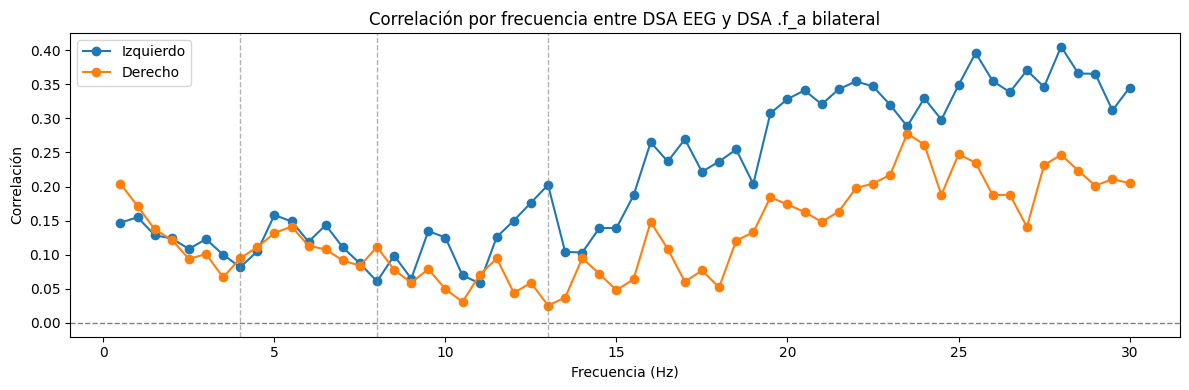

In [35]:
plt.figure(figsize=(12, 4))

plt.plot(
    df_corr_freq_L["frecuencia_Hz"],
    df_corr_freq_L["correlacion"],
    marker="o",
    label="Izquierdo"
)

plt.plot(
    df_corr_freq_R["frecuencia_Hz"],
    df_corr_freq_R["correlacion"],
    marker="o",
    label="Derecho"
)

for f in [4, 8, 13]:
    plt.axvline(f, color="gray", linestyle="--", linewidth=1, alpha=0.6)

plt.axhline(0, color="gray", linestyle="--", linewidth=1)

plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Correlación")
plt.title("Correlación por frecuencia entre DSA EEG y DSA .f_a bilateral")
plt.legend()
plt.tight_layout()
plt.show()

### Suavizado + shift

In [36]:
# ============================================================
# Suavizado + shift bilateral
# ============================================================

ventanas_sp_smooth = [5, 10, 30, 60]
shifts_prueba = range(-60, 61)

# Izquierda
df_suav_shift_L = fun_dsa.probar_suavizado_y_shifts(
    dsa_eeg_L_comp,
    dsa_fa_L_comp,
    ventanas_suavizado=ventanas_sp_smooth,
    shifts=shifts_prueba
)

df_suav_shift_L = df_suav_shift_L.rename(columns={
    "Pearson": "Pearson_L",
    "Spearman": "Spearman_L",
    "MAE": "MAE_L",
    "RMSE": "RMSE_L"
})


# Derecha
df_suav_shift_R = fun_dsa.probar_suavizado_y_shifts(
    dsa_eeg_R_comp,
    dsa_fa_R_comp,
    ventanas_suavizado=ventanas_sp_smooth,
    shifts=shifts_prueba
)

df_suav_shift_R = df_suav_shift_R.rename(columns={
    "Pearson": "Pearson_R",
    "Spearman": "Spearman_R",
    "MAE": "MAE_R",
    "RMSE": "RMSE_R"
})


# Unir por suavizado y shift
df_suav_shift_bilat = df_suav_shift_L.merge(
    df_suav_shift_R,
    on=["suavizado_s", "shift_s"],
    how="inner"
)


# Métricas medias bilaterales
df_suav_shift_bilat["Pearson_medio"] = (
    df_suav_shift_bilat["Pearson_L"] +
    df_suav_shift_bilat["Pearson_R"]
) / 2

df_suav_shift_bilat["Spearman_medio"] = (
    df_suav_shift_bilat["Spearman_L"] +
    df_suav_shift_bilat["Spearman_R"]
) / 2

df_suav_shift_bilat["MAE_medio"] = (
    df_suav_shift_bilat["MAE_L"] +
    df_suav_shift_bilat["MAE_R"]
) / 2

df_suav_shift_bilat["RMSE_medio"] = (
    df_suav_shift_bilat["RMSE_L"] +
    df_suav_shift_bilat["RMSE_R"]
) / 2


# Ver mejores combinaciones
display(
    df_suav_shift_bilat
    .sort_values("Pearson_medio", ascending=False)
    .head(10)
)

,suavizado_s,shift_s,Pearson_L,Spearman_L,MAE_L,RMSE_L,Pearson_R,Spearman_R,MAE_R,RMSE_R,Pearson_medio,Spearman_medio,MAE_medio,RMSE_medio
309,30,7,0.889778,0.856916,0.365214,0.467799,0.934583,0.925900,0.275367,0.361980,0.912181,0.891408,0.320291,0.414889
310,30,8,0.889587,0.856549,0.365338,0.468140,0.934600,0.926091,0.275093,0.361936,0.912094,0.891320,0.320215,0.415038
308,30,6,0.889658,0.856840,0.365633,0.468120,0.934335,0.925362,0.276172,0.362659,0.911997,0.891101,0.320903,0.415389
311,30,9,0.889091,0.855748,0.365966,0.469125,0.934382,0.925923,0.275343,0.362543,0.911736,0.890835,0.320654,0.415834
307,30,5,0.889240,0.856335,0.366596,0.469069,0.933853,0.924470,0.277485,0.363980,0.911547,0.890403,0.322041,0.416525
415,60,-8,0.891771,0.861006,0.365580,0.463402,0.930831,0.922525,0.285857,0.372265,0.911301,0.891765,0.325719,0.417833
416,60,-7,0.891642,0.860871,0.365582,0.463656,0.930930,0.922699,0.285596,0.372011,0.911286,0.891785,0.325589,0.417834
414,60,-9,0.891832,0.861006,0.365723,0.463293,0.930697,0.922267,0.286195,0.372614,0.911265,0.891636,0.325959,0.417953
417,60,-6,0.891450,0.860607,0.365720,0.464051,0.930978,0.922752,0.285468,0.371901,0.911214,0.891680,0.325594,0.417976
413,60,-10,0.891808,0.860872,0.366001,0.463362,0.930510,0.921901,0.286618,0.373102,0.911159,0.891386,0.326310,0.418232


### Elegir mejor suavizado + shift bilateral

In [37]:
mejor_bilat_pearson = (
    df_suav_shift_bilat
    .sort_values("Pearson_medio", ascending=False)
    .iloc[0]
)

mejor_bilat_spearman = (
    df_suav_shift_bilat
    .sort_values("Spearman_medio", ascending=False)
    .iloc[0]
)

df_resumen_final_bilat = pd.DataFrame([
    {
        "criterio": "Mejor Pearson medio",
        "suavizado_s": mejor_bilat_pearson["suavizado_s"],
        "shift_s": mejor_bilat_pearson["shift_s"],
        "Pearson_L": mejor_bilat_pearson["Pearson_L"],
        "Pearson_R": mejor_bilat_pearson["Pearson_R"],
        "Pearson_medio": mejor_bilat_pearson["Pearson_medio"],
        "Spearman_L": mejor_bilat_pearson["Spearman_L"],
        "Spearman_R": mejor_bilat_pearson["Spearman_R"],
        "Spearman_medio": mejor_bilat_pearson["Spearman_medio"],
        "MAE_medio": mejor_bilat_pearson["MAE_medio"],
        "RMSE_medio": mejor_bilat_pearson["RMSE_medio"],
    },
    {
        "criterio": "Mejor Spearman medio",
        "suavizado_s": mejor_bilat_spearman["suavizado_s"],
        "shift_s": mejor_bilat_spearman["shift_s"],
        "Pearson_L": mejor_bilat_spearman["Pearson_L"],
        "Pearson_R": mejor_bilat_spearman["Pearson_R"],
        "Pearson_medio": mejor_bilat_spearman["Pearson_medio"],
        "Spearman_L": mejor_bilat_spearman["Spearman_L"],
        "Spearman_R": mejor_bilat_spearman["Spearman_R"],
        "Spearman_medio": mejor_bilat_spearman["Spearman_medio"],
        "MAE_medio": mejor_bilat_spearman["MAE_medio"],
        "RMSE_medio": mejor_bilat_spearman["RMSE_medio"],
    }
])

display(df_resumen_final_bilat)

,criterio,suavizado_s,shift_s,Pearson_L,Pearson_R,Pearson_medio,Spearman_L,Spearman_R,Spearman_medio,MAE_medio,RMSE_medio
0,Mejor Pearson medio,30.0,7.0,0.889778,0.934583,0.912181,0.856916,0.925900,0.891408,0.320291,0.414889
1,Mejor Spearman medio,60.0,-7.0,0.891642,0.930930,0.911286,0.860871,0.922699,0.891785,0.325589,0.417834


In [38]:
suavizado_final_bilat = int(mejor_bilat_pearson["suavizado_s"])
shift_final_bilat = int(mejor_bilat_pearson["shift_s"])

print("Suavizado final bilateral:", suavizado_final_bilat)
print("Shift final bilateral:", shift_final_bilat)

Suavizado final bilateral: 30
Shift final bilateral: 7


## Suavizado limpio

In [39]:
# ============================================================
# Suavizado temporal bilateral
# ============================================================

suavizado_final_bilat = 30

dsa_eeg_izq_suav = dsa_eeg_izq.copy().rolling(
    window=suavizado_final_bilat,
    min_periods=1,
    center=False
).mean()

dsa_eeg_der_suav = dsa_eeg_der.copy().rolling(
    window=suavizado_final_bilat,
    min_periods=1,
    center=False
).mean()

## Aplicar máscara común al final

In [40]:
# ============================================================
# Aplicar máscara común bilateral al final
# ============================================================

dsa_eeg_izq_suav_plot = dsa_eeg_izq_suav.copy()
dsa_eeg_der_suav_plot = dsa_eeg_der_suav.copy()

dsa_eeg_izq_suav_plot.loc[mask_total_bilat.values, :] = np.nan
dsa_eeg_der_suav_plot.loc[mask_total_bilat.values, :] = np.nan

## Preparar escala de color común para suavizadas

In [66]:
# ============================================================
# Escala común para DSA suavizadas izquierda/derecha
# ============================================================

matriz_suav_izq, matriz_suav_der, vmin_suav, vmax_suav, norm_suav_bilat, cmap_suav_bilat = (
    fun_dsa_b.preparar_escala_color_dsa_bilateral(
        dsa_eeg_izq_suav_plot,
        dsa_eeg_der_suav_plot,
        gamma=0.25
    )
)

print("Rango suavizada bilateral:")
print("vmin:", vmin_suav)
print("vmax:", vmax_suav)

Rango suavizada bilateral:
vmin: 71.8876990120877
vmax: 103.83723787037275


### Comprobación de bandas blancas

In [42]:
# ============================================================
# Comprobación de bandas blancas
# ============================================================

mask_blanca_izq_directa = dsa_eeg_izq_plot.isna().all(axis=1)
mask_blanca_der_directa = dsa_eeg_der_plot.isna().all(axis=1)

mask_blanca_izq_suav = dsa_eeg_izq_suav_plot.isna().all(axis=1)
mask_blanca_der_suav = dsa_eeg_der_suav_plot.isna().all(axis=1)

print("Bandas blancas izquierda directa vs suavizada:")
print((mask_blanca_izq_directa == mask_blanca_izq_suav).all())
print("Diferencias izquierda:", (mask_blanca_izq_directa != mask_blanca_izq_suav).sum())

print("\nBandas blancas derecha directa vs suavizada:")
print((mask_blanca_der_directa == mask_blanca_der_suav).all())
print("Diferencias derecha:", (mask_blanca_der_directa != mask_blanca_der_suav).sum())

Bandas blancas izquierda directa vs suavizada:
True
Diferencias izquierda: 0

Bandas blancas derecha directa vs suavizada:
True
Diferencias derecha: 0


## Aplicar shift bilateral manteniendo duración original

In [44]:
# ============================================================
# Suavizado + shift bilateral manteniendo duración original
# ============================================================

shift_final_bilat = 7

# Matrices vacías del mismo tamaño
dsa_eeg_izq_suav_shift_full = pd.DataFrame(
    np.nan,
    index=dsa_eeg_izq_suav.index,
    columns=dsa_eeg_izq_suav.columns
)

dsa_eeg_der_suav_shift_full = pd.DataFrame(
    np.nan,
    index=dsa_eeg_der_suav.index,
    columns=dsa_eeg_der_suav.columns
)

# Desplazar hacia delante
dsa_eeg_izq_suav_shift_full.iloc[shift_final_bilat:, :] = (
    dsa_eeg_izq_suav.iloc[:-shift_final_bilat, :].to_numpy()
)

dsa_eeg_der_suav_shift_full.iloc[shift_final_bilat:, :] = (
    dsa_eeg_der_suav.iloc[:-shift_final_bilat, :].to_numpy()
)

# Aplicar máscara común bilateral al final
dsa_eeg_izq_suav_shift_full.loc[mask_total_bilat.values, :] = np.nan
dsa_eeg_der_suav_shift_full.loc[mask_total_bilat.values, :] = np.nan

## Escala común para suavizada + shift

In [76]:
# ============================================================
# Escala común para DSA suavizadas + shift
# ============================================================

matriz_shift_izq, matriz_shift_der, vmin_shift, vmax_shift, norm_shift_bilat, cmap_shift_bilat = (
    fun_dsa_b.preparar_escala_color_dsa_bilateral(
        dsa_eeg_izq_suav_shift_full,
        dsa_eeg_der_suav_shift_full,
        gamma=0.55
        
    )
)

print("Rango suavizada + shift bilateral:")
print("vmin:", vmin_shift)
print("vmax:", vmax_shift)

Rango suavizada + shift bilateral:
vmin: 71.88391891848265
vmax: 103.90388982409324


### Comprobación de formas

In [77]:
# ============================================================
# Comprobación de formas y tiempos
# ============================================================

print("DSA f_a izquierda:", dsa_plot_fa_L_mask.shape)
print("DSA f_a derecha:", dsa_plot_fa_R_mask.shape)

print("DSA EEG izquierda directa:", dsa_eeg_izq_plot.shape)
print("DSA EEG derecha directa:", dsa_eeg_der_plot.shape)

print("DSA EEG izquierda suavizada:", dsa_eeg_izq_suav_plot.shape)
print("DSA EEG derecha suavizada:", dsa_eeg_der_suav_plot.shape)

print("DSA EEG izquierda suavizada + shift:", dsa_eeg_izq_suav_shift_full.shape)
print("DSA EEG derecha suavizada + shift:", dsa_eeg_der_suav_shift_full.shape)

print("\n¿Tiempos f_a y EEG iguales?")
print(
    (tiempo_fa_bilat.reset_index(drop=True) == tiempo_eeg_bilat.reset_index(drop=True)).all()
)

print("\nRango DSA EEG izquierda directa:")
print(np.nanmin(dsa_eeg_izq_plot.values), np.nanmax(dsa_eeg_izq_plot.values))

print("\nRango DSA EEG derecha directa:")
print(np.nanmin(dsa_eeg_der_plot.values), np.nanmax(dsa_eeg_der_plot.values))

print("\nRango DSA f_a izquierda:")
print(np.nanmin(dsa_plot_fa_L_mask.values), np.nanmax(dsa_plot_fa_L_mask.values))

print("\nRango DSA f_a derecha:")
print(np.nanmin(dsa_plot_fa_R_mask.values), np.nanmax(dsa_plot_fa_R_mask.values))

print("\nRango DSA suavizada + shift izquierda:")
print(np.nanmin(dsa_eeg_izq_suav_shift_full.values), np.nanmax(dsa_eeg_izq_suav_shift_full.values))

print("\nRango DSA suavizada + shift derecha:")
print(np.nanmin(dsa_eeg_der_suav_shift_full.values), np.nanmax(dsa_eeg_der_suav_shift_full.values))

DSA f_a izquierda: (2712, 60)
DSA f_a derecha: (2712, 60)
DSA EEG izquierda directa: (2712, 60)
DSA EEG derecha directa: (2712, 60)
DSA EEG izquierda suavizada: (2712, 60)
DSA EEG derecha suavizada: (2712, 60)
DSA EEG izquierda suavizada + shift: (2712, 60)
DSA EEG derecha suavizada + shift: (2712, 60)

¿Tiempos f_a y EEG iguales?
True

Rango DSA EEG izquierda directa:
46.16160086071149 122.50951504083179

Rango DSA EEG derecha directa:
46.92148813964039 126.08862114018314

Rango DSA f_a izquierda:
55.75 98.29

Rango DSA f_a derecha:
57.63 101.07

Rango DSA suavizada + shift izquierda:
67.59983113548222 109.53564975883764

Rango DSA suavizada + shift derecha:
59.21776251512816 108.83003945632294


## Visualizar suavizada + shift bilateral

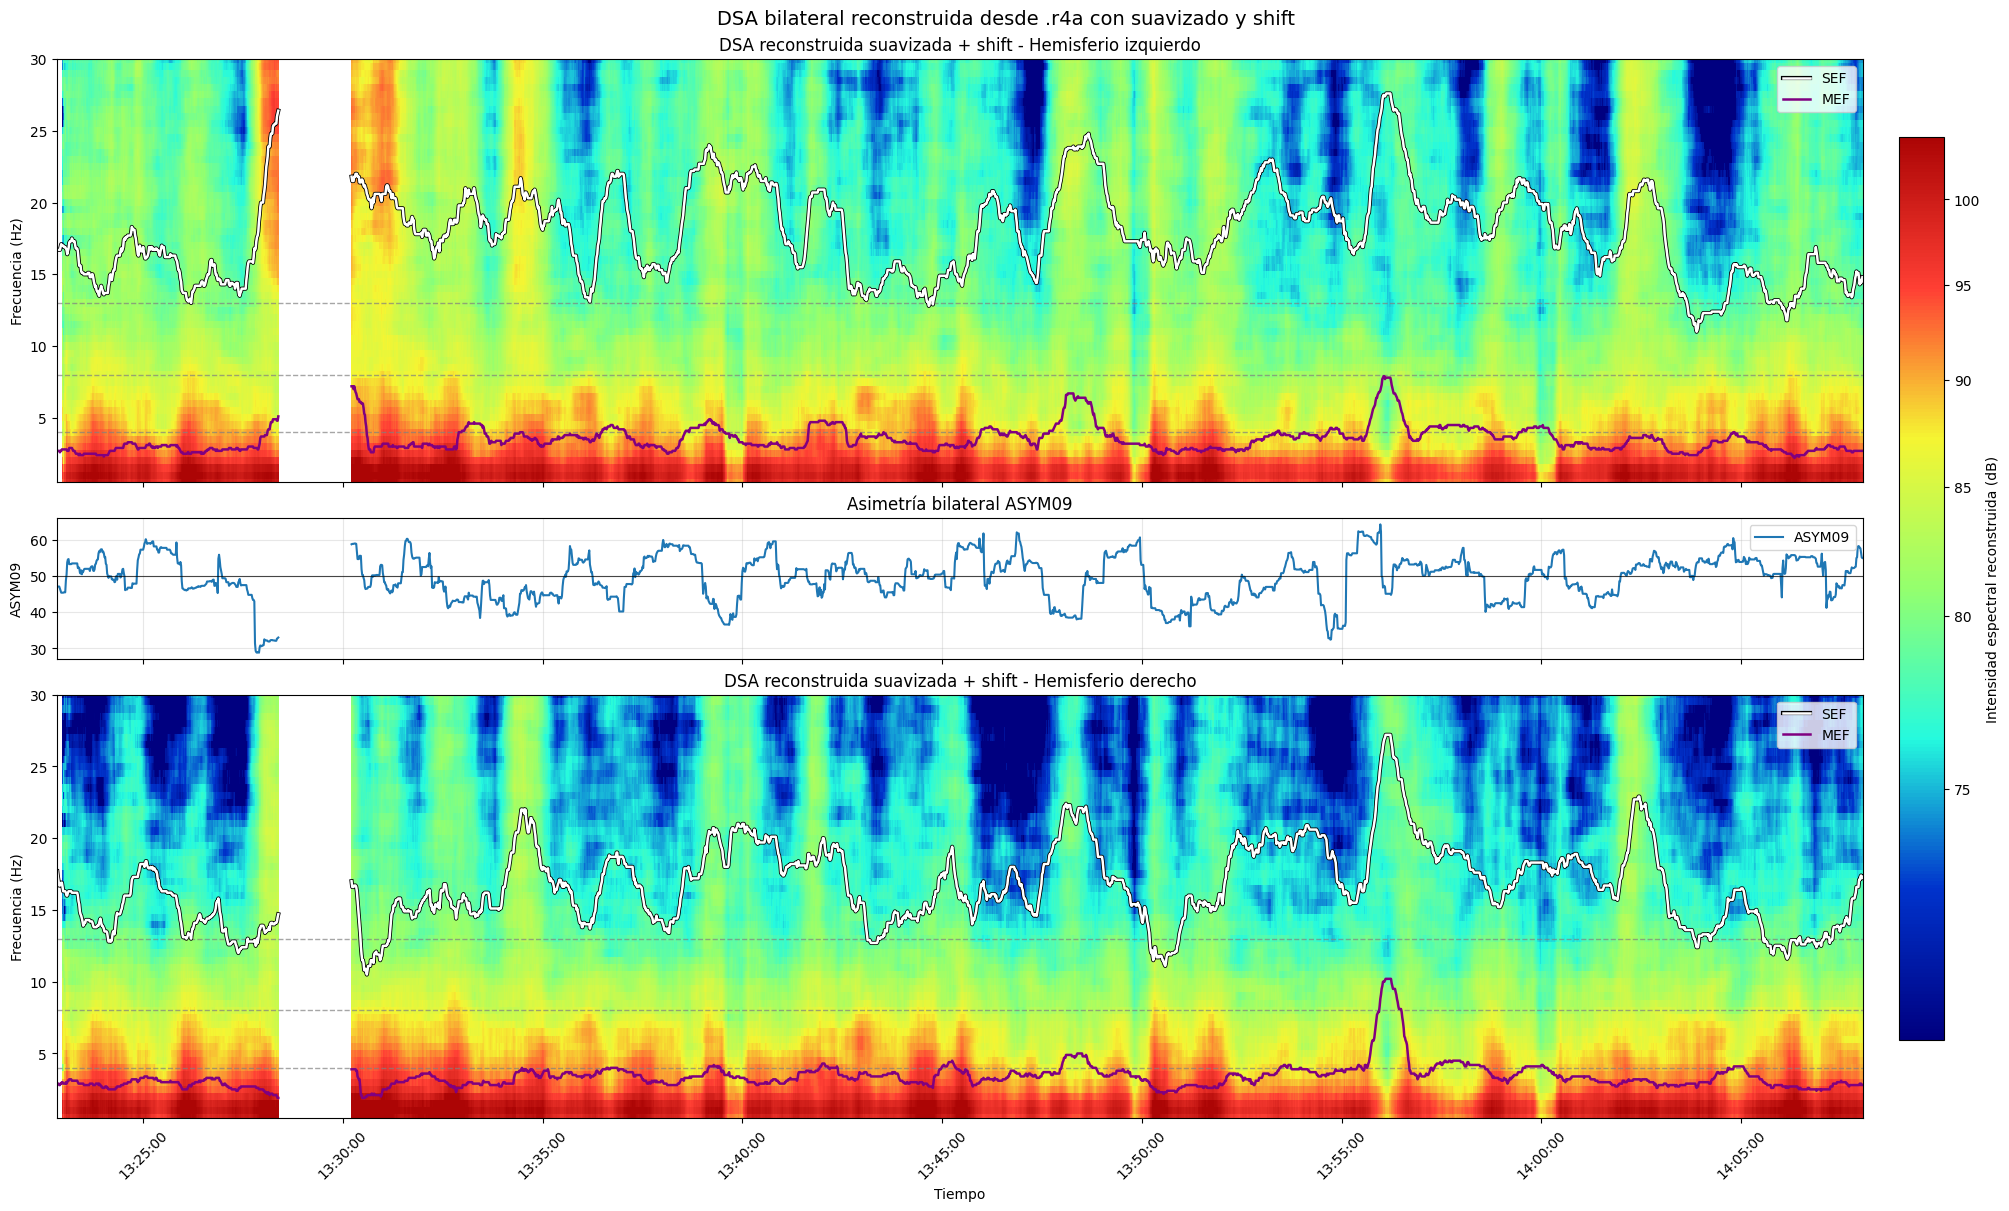

In [78]:
fig, axes = fun_plot.plot_dsa_bilateral_con_sef_mef(
    tiempo=tiempo_eeg_bilat,
    frecuencias=dsa_eeg_izq_suav_shift_full.columns.astype(float),
    matriz_izq=matriz_shift_izq,
    matriz_der=matriz_shift_der,
    norm=norm_shift_bilat,
    cmap=cmap_shift_bilat,
    df_merge_izq=df_merge_eeg_izq,
    df_merge_der=df_merge_eeg_der,
    mask_izq=mask_total_bilat,
    mask_der=mask_total_bilat,
    asimetria=df_merge_eeg_izq["ASYM09"] if "ASYM09" in df_merge_eeg_izq.columns else None,
    titulo_izq="DSA reconstruida suavizada + shift - Hemisferio izquierdo",
    titulo_der="DSA reconstruida suavizada + shift - Hemisferio derecho",
    titulo_general="DSA bilateral reconstruida desde .r4a con suavizado y shift",
    etiqueta_colorbar="Intensidad espectral reconstruida (dB)"
)

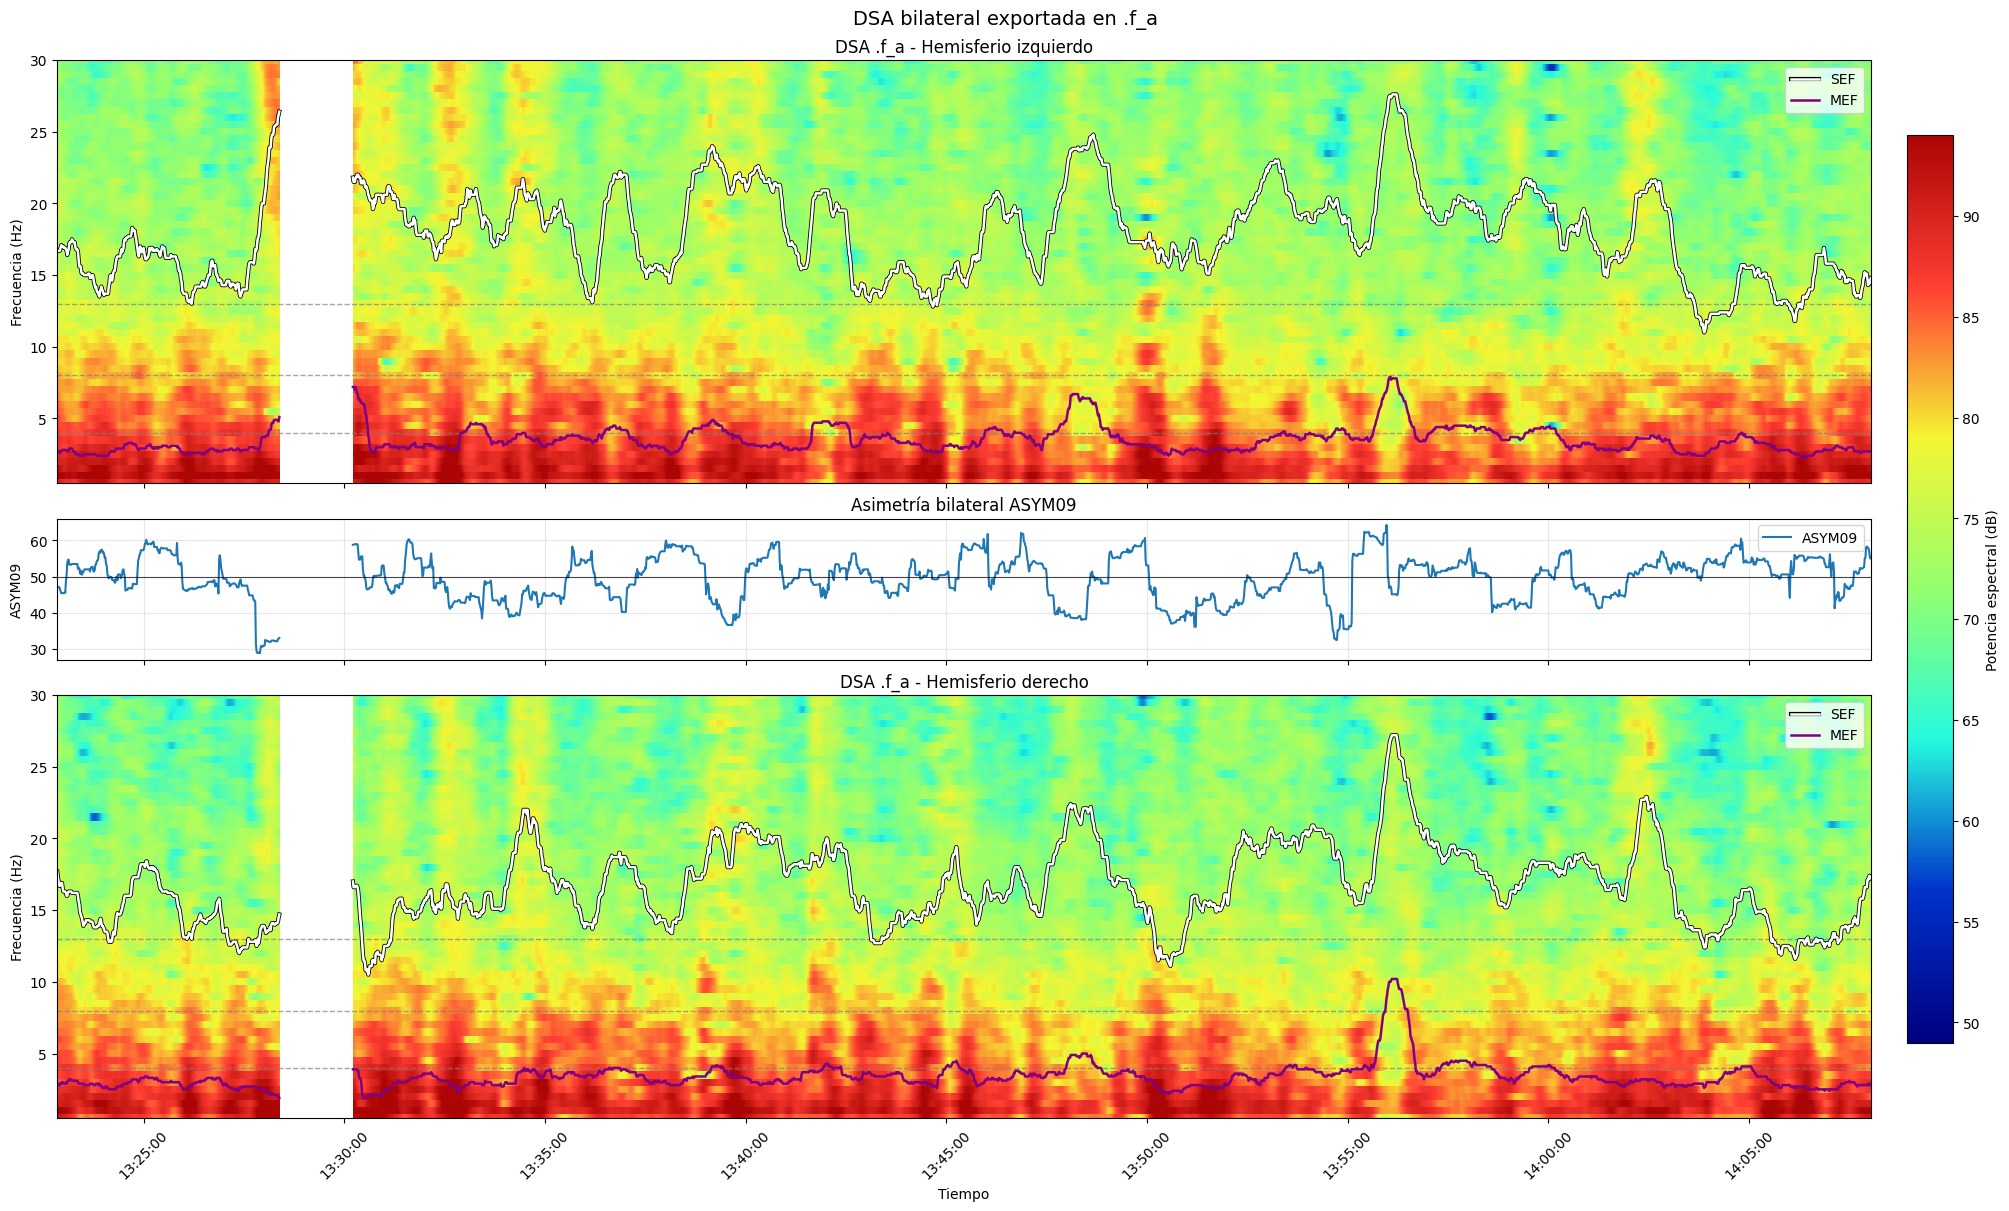

In [54]:
fig_fa, axes_fa = fun_plot.plot_dsa_bilateral_con_sef_mef(
    tiempo=tiempo_fa_bilat,
    frecuencias=frecuencias_fa,
    matriz_izq=matriz_fa_L,
    matriz_der=matriz_fa_R,
    norm=norm_fa_bilat,
    cmap=cmap_fa_bilat,
    df_merge_izq=df_merge_fa_L,
    df_merge_der=df_merge_fa_R,
    mask_izq=mask_total_fa_bilat,
    mask_der=mask_total_fa_bilat,
    asimetria=df_merge_fa_L["ASYM09"],
    titulo_izq="DSA .f_a - Hemisferio izquierdo",
    titulo_der="DSA .f_a - Hemisferio derecho",
    titulo_general="DSA bilateral exportada en .f_a",
    etiqueta_colorbar="Potencia espectral (dB)"
)

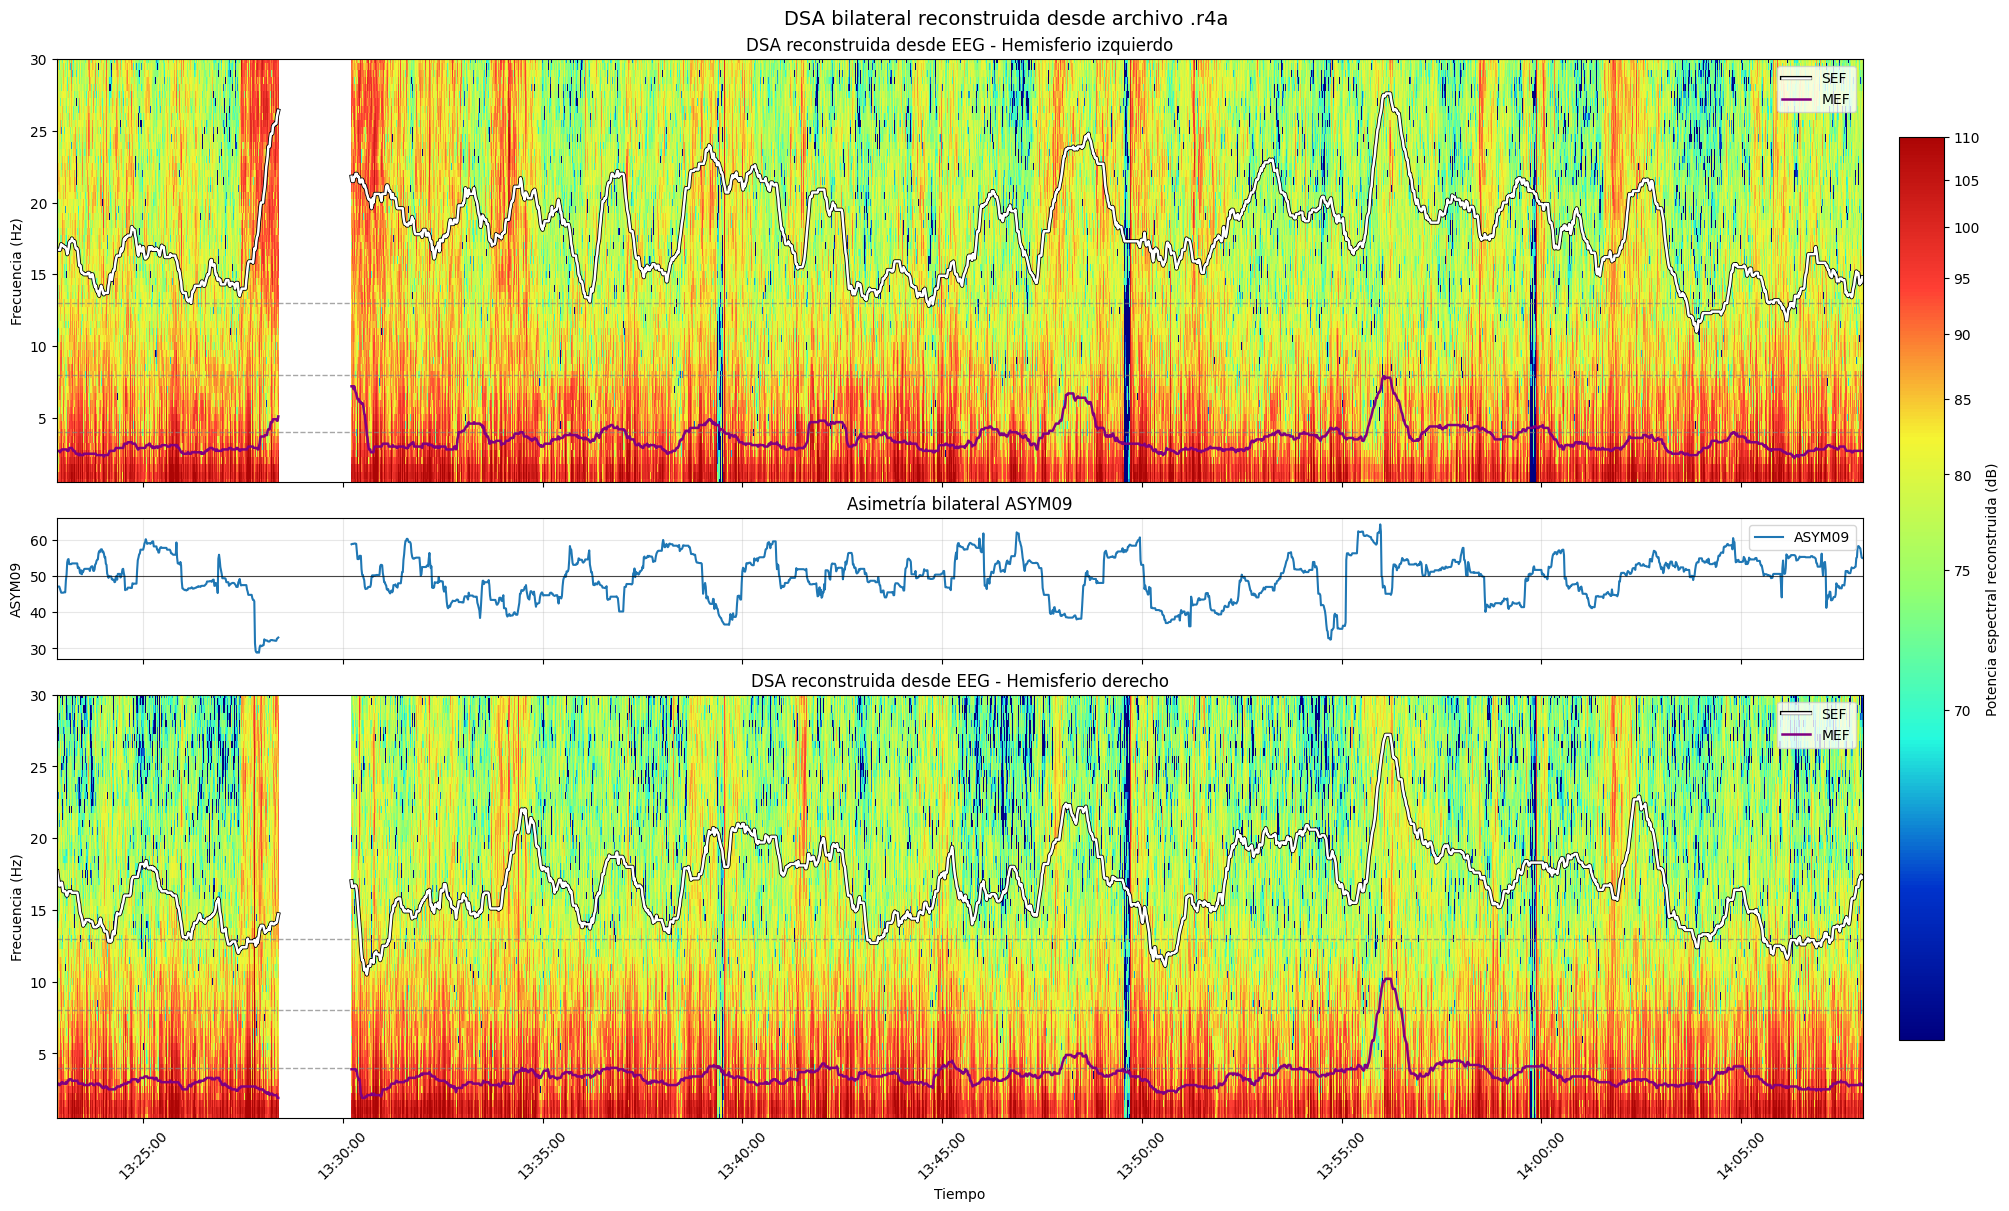

In [55]:
fig_eeg, axes_eeg = fun_plot.plot_dsa_bilateral_con_sef_mef(
    tiempo=tiempo_eeg_bilat,
    frecuencias=dsa_eeg_izq_plot.columns.astype(float),
    matriz_izq=matriz_eeg_izq,
    matriz_der=matriz_eeg_der,
    norm=norm_eeg_bilat,
    cmap=cmap_eeg_bilat,
    df_merge_izq=df_merge_eeg_izq,
    df_merge_der=df_merge_eeg_der,
    mask_izq=mask_total_bilat,
    mask_der=mask_total_bilat,
    asimetria=df_merge_eeg_izq["ASYM09"] if "ASYM09" in df_merge_eeg_izq.columns else None,
    titulo_izq="DSA reconstruida desde EEG - Hemisferio izquierdo",
    titulo_der="DSA reconstruida desde EEG - Hemisferio derecho",
    titulo_general="DSA bilateral reconstruida desde archivo .r4a",
    etiqueta_colorbar="Potencia espectral reconstruida (dB)"
)

In [ ]:
ruta_spa_bilat_h = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_advanced/bilateral/M-Py5D-04301923\DH04301923\L04301923.spa"
df_spa_raw_h = fau.procesar_spa(ruta_spa_bilat_h)

df_spa_limpio_h = fun_dsa_b.limpiar_spa_bilateral(df_spa_raw_h)


display(df_spa_limpio_h.head())